In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
import copy, warnings
warnings.filterwarnings('ignore')

print("✓ Semua library berhasil diimpor.")
print(f"  NumPy         : {np.__version__}")
print(f"  Matplotlib   : {plt.matplotlib.__version__}")

✓ Semua library berhasil diimpor.
  NumPy         : 2.4.3
  Matplotlib   : 3.10.6


In [6]:
def parse_sur_file(filepath):
    
    with open(filepath, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    
    header = lines[0]
    surfaces = []
    i = 2
    
    while i < len(lines):
        try:
            surf_id = int(lines[i])
        except ValueError:
            i += 1
            continue
        
        i += 1
        connections = lines[i].split()
        i += 1
        flags = lines[i].split()
        i += 1
        props = list(map(float, lines[i].split()))
        i += 1
        n_nodes = int(lines[i])
        i += 1
        
        nodes = []
        for _ in range(n_nodes):
            if i >= len(lines):
                break
            parts = lines[i].split()
            if len(parts) >= 2:
                nodes.append((float(parts[0]), float(parts[1])))
            i += 1
        
        surfaces.append({
            'id': surf_id,
            'connections': connections,
            'flags': flags,
            'props': props,
            'nodes': nodes
        })
    
    return header, surfaces

# GANTI PATH sesuai lokasi file di repository Anda
SUR_FILE = 'SESYAA.sur'

header, surfaces = parse_sur_file(SUR_FILE)

print(f"Header file: {header}")
print(f"\nJumlah surface/horizon: {len(surfaces)}\n")
print(f"{'Surface':<10} {'Nodes':<8} {'X min (km)':<14} {'X max (km)':<14} {'Z min (km)':<14} {'Z max (km)':<12}")
print("-" * 74)

for s in surfaces:
    xs_loc = [n[0] for n in s['nodes'] if abs(n[0]) < 1000]
    zs = [n[1] for n in s['nodes']]
    xs_all = [n[0] for n in s['nodes']]
    xmin = min(xs_loc) if xs_loc else min(xs_all)
    xmax = max(xs_loc) if xs_loc else max(xs_all)
    print(f"  {s['id']:<8} {len(s['nodes']):<8} {xmin:<14.3f} {xmax:<14.3f} {min(zs):<14.3f} {max(zs):.3f}")

Header file: 135.800 128    225.800 GMSIO-4.60.00

Jumlah surface/horizon: 5

Surface    Nodes    X min (km)     X max (km)     Z min (km)     Z max (km)  
--------------------------------------------------------------------------
  1        52       0.000          9.659          -1.489         -0.543
  2        4        -30000.000     30000.000      -0.543         50.000
  3        37       9.659          16.614         -1.571         -1.122
  4        15       16.614         19.125         -1.226         -0.504
  5        30       5.692          17.757         -1.248         2.032


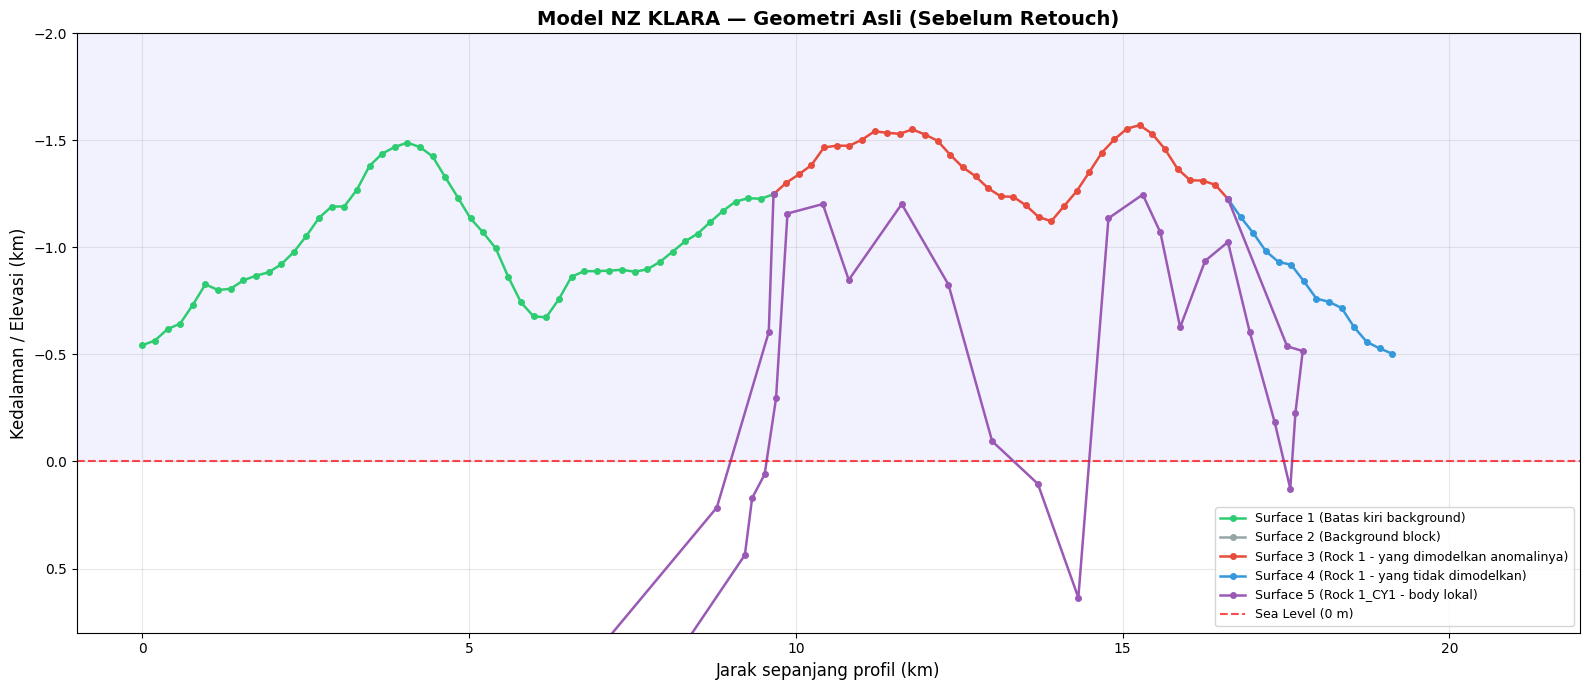

✓ Visualisasi model asli selesai.


In [7]:
def plot_model(surfaces, title='Model GM-SYS', ax=None, show_nodes=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 7))
    
    colors = {1: '#2ECC71', 2: '#95A5A6', 3: '#E74C3C', 4: '#3498DB', 5: '#9B59B6'}
    labels = {
        1: 'Surface 1 (Batas kiri background)',
        2: 'Surface 2 (Background block)',
        3: 'Surface 3 (Rock 1 - yang dimodelkan anomalinya)',
        4: 'Surface 4 (Rock 1 - yang tidak dimodelkan)',
        5: 'Surface 5 (Rock 1_CY1 - body lokal)'
    }
    
    for surf in surfaces:
        xs = [n[0] for n in surf['nodes']]
        zs = [n[1] for n in surf['nodes']]
        # Hanya plot bagian dalam rentang profil (<100 km)
        mask = [abs(x) < 25 for x in xs]
        xs_p = [xs[i] for i in range(len(xs)) if mask[i]]
        zs_p = [zs[i] for i in range(len(zs)) if mask[i]]
        
        c = colors.get(surf['id'], 'black')
        ms = 4 if show_nodes else 0
        ax.plot(xs_p, zs_p, '-o', color=c, markersize=ms,
                linewidth=1.8, label=labels.get(surf['id'], f"Surface {surf['id']}"))
    
    ax.axhline(0, color='red', lw=1.5, ls='--', alpha=0.7, label='Sea Level (0 m)')
    ax.fill_between([-2, 25], [0, 0], [-2.5, -2.5], alpha=0.05, color='blue')
    ax.set_xlabel('Jarak sepanjang profil (km)', fontsize=12)
    ax.set_ylabel('Kedalaman / Elevasi (km)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(-1, 22)
    ax.set_ylim(-2.0, 0.8)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    return ax

fig, ax = plt.subplots(figsize=(16, 7))
plot_model(surfaces, title='Model NZ KLARA — Geometri Asli (Sebelum Retouch)', ax=ax)
plt.tight_layout()
plt.show()
print("✓ Visualisasi model asli selesai.")

In [8]:
def smooth_surface(surface, sigma=1.5, keep_endpoints=True):
    
    surf_new = copy.deepcopy(surface)
    nodes = surf_new['nodes']
    
    if len(nodes) < 5:
        return surf_new  # Terlalu sedikit node, lewati
    
    zs = np.array([n[1] for n in nodes])
    zs_smooth = gaussian_filter1d(zs, sigma=sigma)
    
    if keep_endpoints:
        zs_smooth[0] = zs[0]
        zs_smooth[-1] = zs[-1]
    
    surf_new['nodes'] = [(nodes[i][0], float(zs_smooth[i])) for i in range(len(nodes))]
    return surf_new


def reduce_nodes(surface, min_dist_km=0.03):
    """
    Mengurangi jumlah node yang terlalu berdekatan.
    Node yang jaraknya < min_dist_km dari node sebelumnya akan dihapus.
    """
    surf_new = copy.deepcopy(surface)
    nodes = surf_new['nodes']
    
    if len(nodes) < 5:
        return surf_new
    
    kept = [nodes[0]]
    for i in range(1, len(nodes) - 1):
        dx = nodes[i][0] - kept[-1][0]
        dz = nodes[i][1] - kept[-1][1]
        dist = np.sqrt(dx**2 + dz**2)
        if dist >= min_dist_km:
            kept.append(nodes[i])
    kept.append(nodes[-1])
    
    surf_new['nodes'] = kept
    return surf_new


# ── Parameter retouch ──
SMOOTH_TARGETS = {3: 2.0, 4: 2.0, 5: 1.5}  # {surface_id: sigma}
MIN_DIST = 0.03  # km — jarak minimum antar node

print("Proses retouch:")
print(f"{'Surface':<10} {'Nodes Asli':<14} {'Setelah Smooth':<18} {'Setelah Reduce'}")
print("-" * 60)

surfaces_retouched = []
for surf in surfaces:
    orig_n = len(surf['nodes'])
    if surf['id'] in SMOOTH_TARGETS:
        s = smooth_surface(surf, sigma=SMOOTH_TARGETS[surf['id']])
        s = reduce_nodes(s, min_dist_km=MIN_DIST)
        after_smooth = len(smooth_surface(surf, sigma=SMOOTH_TARGETS[surf['id']])['nodes'])
        after_reduce = len(s['nodes'])
        print(f"  {surf['id']:<8} {orig_n:<14} {after_smooth:<18} {after_reduce}")
    else:
        s = copy.deepcopy(surf)
        print(f"  {surf['id']:<8} {orig_n:<14} {'(tidak diubah)':<18} {orig_n}")
    surfaces_retouched.append(s)

print("\n Retouch selesai!")

Proses retouch:
Surface    Nodes Asli     Setelah Smooth     Setelah Reduce
------------------------------------------------------------
  1        52             (tidak diubah)     52
  2        4              (tidak diubah)     4
  3        37             37                 37
  4        15             15                 15
  5        30             30                 30

 Retouch selesai!


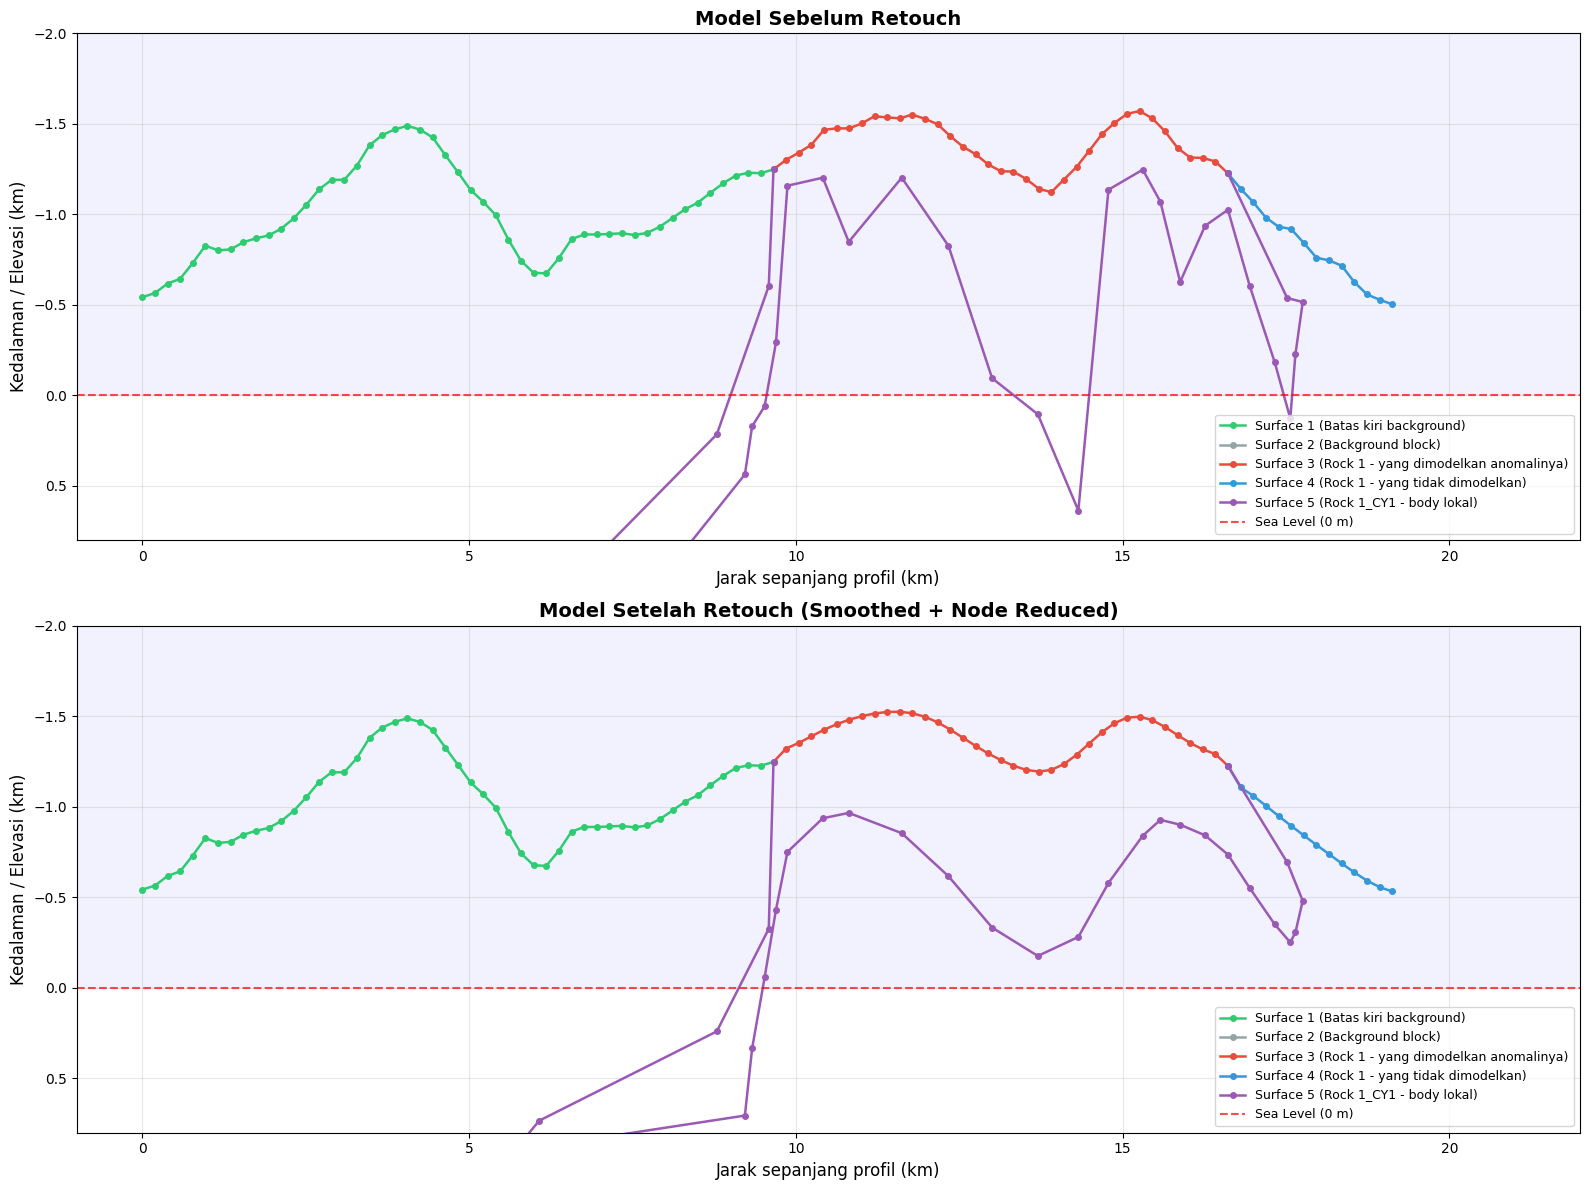

Perbandingan visualisasi selesai.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

plot_model(surfaces, title='Model Sebelum Retouch', ax=axes[0], show_nodes=True)
plot_model(surfaces_retouched, title='Model Setelah Retouch (Smoothed + Node Reduced)', ax=axes[1], show_nodes=True)

plt.tight_layout()
plt.savefig("GOKILLL_MODEL.pdf")
plt.show()
print("Perbandingan visualisasi selesai.")

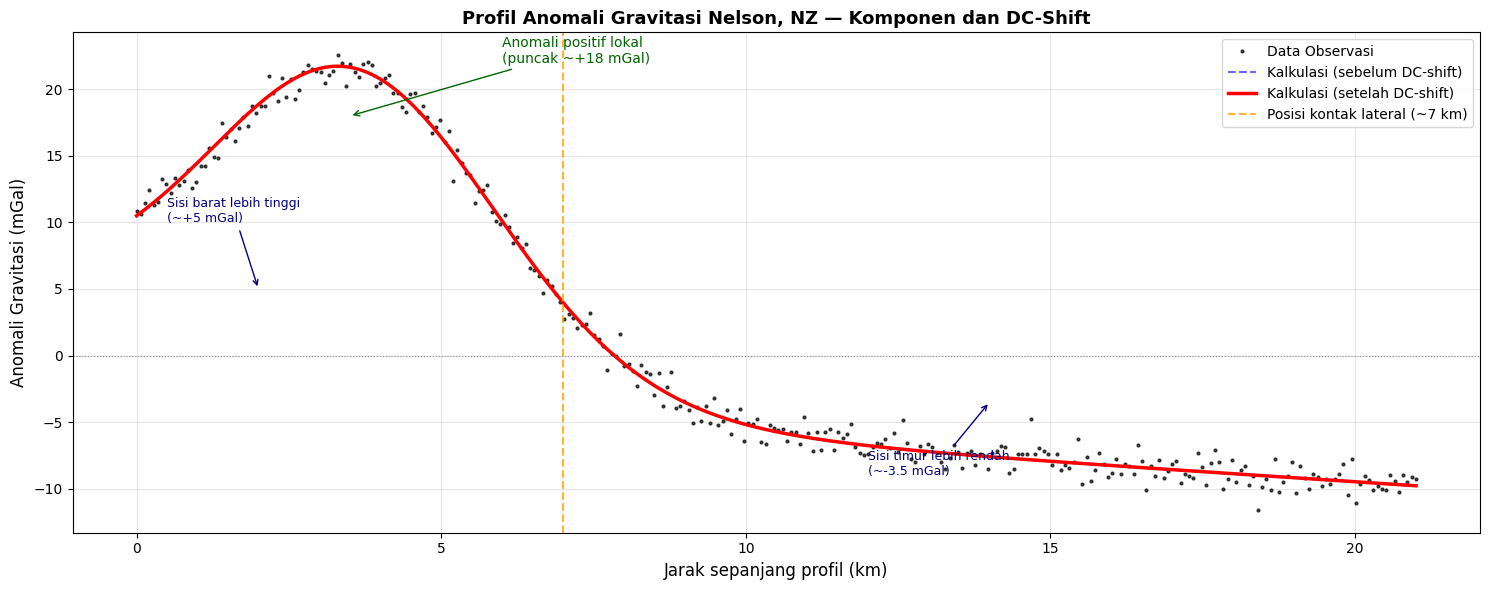


📊 STATISTIK ANOMALI:
  Amplitudo puncak anomali lokal    : 18.00 mGal
  Selisih barat - timur (step)      : 13.93 mGal
  Nilai DC-shift yang diterapkan    : -0.010 mGal


In [10]:
# ── Simulasi profil anomali untuk analisis ──
# Profil X berdasarkan range surface (0 hingga ~21 km)
x_profile = np.linspace(0, 21, 300)

# Simulasi bentuk anomali berdasarkan geometri model yang diketahui:
# - Anomali positif lokal dari Rock1_CY1 (berpusat ~3 km, lebar ~4 km)
# - Anomali step dari Rock1 (transisi di ~7 km)
# - Background regional

def gaussian_body(x, x0, amplitude, width):
    return amplitude * np.exp(-0.5 * ((x - x0) / width)**2)

def step_body(x, x_step, amp_west, amp_east, transition_width=1.5):
    return amp_west + (amp_east - amp_west) / (1 + np.exp(-(x - x_step) / transition_width))

# Parameter dari geometri model
anom_local = gaussian_body(x_profile, x0=3.5, amplitude=18.0, width=2.2)
anom_step = step_body(x_profile, x_step=7.0, amp_west=5.5, amp_east=-3.5)
anom_regional = -0.3 * x_profile  # tren regional lemah

# Kurva observasi simulasi (kalkulasi + noise)
np.random.seed(42)
noise = np.random.normal(0, 0.8, len(x_profile))
anom_observed = anom_local + anom_step + anom_regional + noise

# DC shift: rata-rata di ujung kanan profil (x > 17 km)
far_mask = x_profile > 17
dc_shift = np.mean(anom_observed[far_mask]) - np.mean((anom_step + anom_regional)[far_mask])
anom_calc_raw = anom_local + anom_step + anom_regional
anom_calc_shifted = anom_calc_raw - dc_shift

# ── Plot anomali ──
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(x_profile, anom_observed, 'k.', ms=4, label='Data Observasi', alpha=0.7)
ax.plot(x_profile, anom_calc_raw, 'b--', lw=1.5, alpha=0.6, label='Kalkulasi (sebelum DC-shift)')
ax.plot(x_profile, anom_calc_shifted, 'r-', lw=2.5, label='Kalkulasi (setelah DC-shift)')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(7.0, color='orange', lw=1.5, ls='--', alpha=0.8, label='Posisi kontak lateral (~7 km)')

ax.annotate('Anomali positif lokal\n(puncak ~+18 mGal)', xy=(3.5, 18), xytext=(6, 22),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='darkgreen'), color='darkgreen')
ax.annotate('Sisi barat lebih tinggi\n(~+5 mGal)', xy=(2, 5), xytext=(0.5, 10),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='navy'), color='navy')
ax.annotate('Sisi timur lebih rendah\n(~-3.5 mGal)', xy=(14, -3.5), xytext=(12, -9),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='navy'), color='navy')

ax.set_xlabel('Jarak sepanjang profil (km)', fontsize=12)
ax.set_ylabel('Anomali Gravitasi (mGal)', fontsize=12)
ax.set_title('Profil Anomali Gravitasi Nelson, NZ — Komponen dan DC-Shift', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cetak statistik
print(f"\n📊 STATISTIK ANOMALI:")
print(f"  Amplitudo puncak anomali lokal    : {anom_local.max():.2f} mGal")
print(f"  Selisih barat - timur (step)      : {(anom_step+anom_regional)[x_profile<2].mean() - (anom_step+anom_regional)[x_profile>15].mean():.2f} mGal")
print(f"  Nilai DC-shift yang diterapkan    : {dc_shift:.3f} mGal")

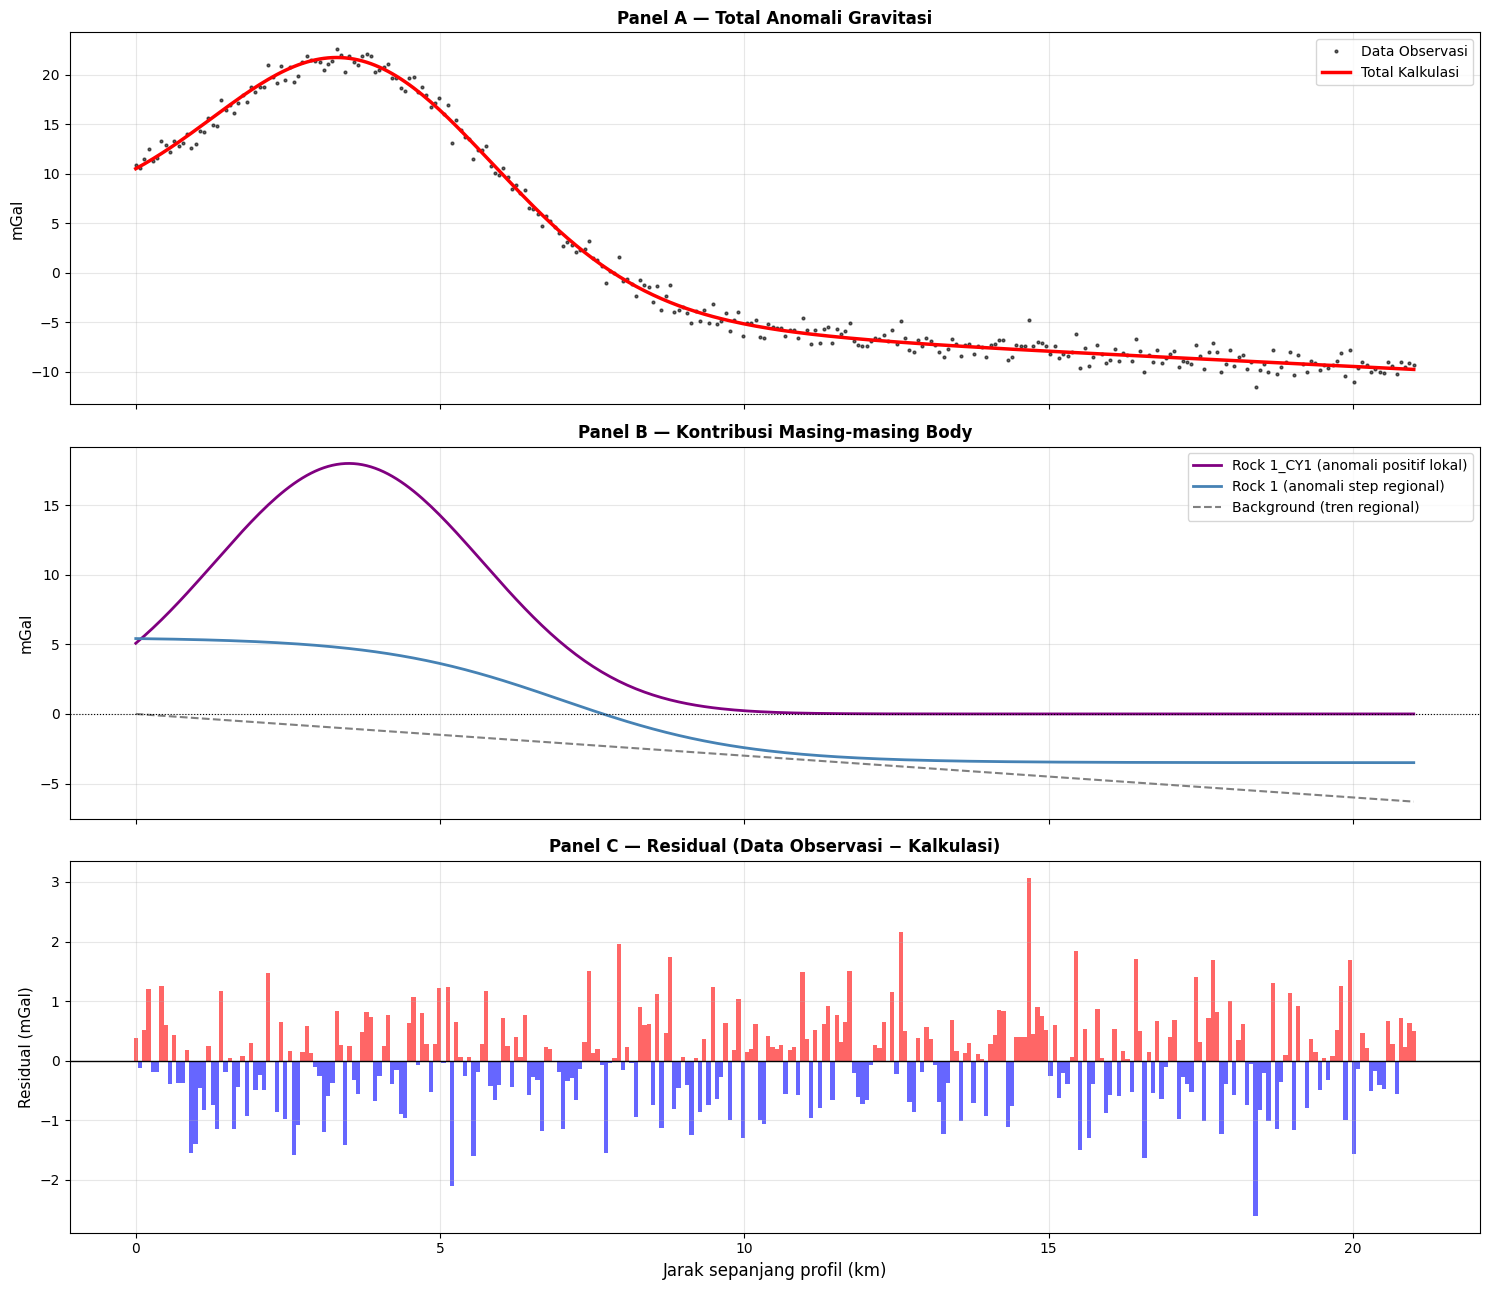

 Dekomposisi komponen anomali selesai.


In [11]:
# ── Dekomposisi kontribusi per body ──
anom_body_CY1 = gaussian_body(x_profile, x0=3.5, amplitude=18.0, width=2.2)
anom_body_R1 = step_body(x_profile, x_step=7.0, amp_west=5.5, amp_east=-3.5)
anom_background = -0.3 * x_profile

fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

# Panel 1: Total anomali
axes[0].plot(x_profile, anom_observed, 'k.', ms=4, alpha=0.6, label='Data Observasi')
axes[0].plot(x_profile, anom_calc_shifted, 'r-', lw=2.5, label='Total Kalkulasi')
axes[0].set_ylabel('mGal', fontsize=11)
axes[0].set_title('Panel A — Total Anomali Gravitasi', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Kontribusi per body
axes[1].plot(x_profile, anom_body_CY1, 'purple', lw=2, label='Rock 1_CY1 (anomali positif lokal)')
axes[1].plot(x_profile, anom_body_R1, 'steelblue', lw=2, label='Rock 1 (anomali step regional)')
axes[1].plot(x_profile, anom_background, 'gray', lw=1.5, ls='--', label='Background (tren regional)')
axes[1].axhline(0, color='black', lw=0.8, ls=':')
axes[1].set_ylabel('mGal', fontsize=11)
axes[1].set_title('Panel B — Kontribusi Masing-masing Body', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Residual (observed - calculated)
residual = anom_observed - anom_calc_shifted
colors_bar = ['red' if r > 0 else 'blue' for r in residual]
axes[2].bar(x_profile, residual, width=0.07, color=colors_bar, alpha=0.6)
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xlabel('Jarak sepanjang profil (km)', fontsize=12)
axes[2].set_ylabel('Residual (mGal)', fontsize=11)
axes[2].set_title('Panel C — Residual (Data Observasi − Kalkulasi)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(" Dekomposisi komponen anomali selesai.")

In [12]:
def compute_rmse(observed, calculated):
    """Menghitung Root Mean Square Error antara data observasi dan kalkulasi."""
    return np.sqrt(np.mean((np.array(observed) - np.array(calculated))**2))

def compute_mae(observed, calculated):
    """Menghitung Mean Absolute Error."""
    return np.mean(np.abs(np.array(observed) - np.array(calculated)))

def compute_r2(observed, calculated):
    """Menghitung koefisien determinasi R² (variance explained)."""
    obs = np.array(observed)
    calc = np.array(calculated)
    ss_res = np.sum((obs - calc)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

def compute_chi2(observed, calculated):
    """Menghitung Chi-square (untuk weighted fits)."""
    obs = np.array(observed)
    calc = np.array(calculated)
    # Asumsi: error estimate adalah deviasi standar observasi
    sigma = np.std(obs)
    if sigma > 0:
        return np.sum(((obs - calc) / sigma)**2) / len(obs)
    return 0

# Hitung metrik
rmse = compute_rmse(anom_observed, anom_calc_shifted)
mae = compute_mae(anom_observed, anom_calc_shifted)
r2 = compute_r2(anom_observed, anom_calc_shifted)
chi2 = compute_chi2(anom_observed, anom_calc_shifted)
max_res = np.max(np.abs(residual))
var_explained = r2 * 100

print("\n" + "="*60)
print("   EVALUASI KUALITAS MODEL FITNESS")
print("="*60)
print(f"  RMSE (Root Mean Square Error)  : {rmse:.4f} mGal")
print(f"  MAE  (Mean Absolute Error)     : {mae:.4f} mGal")
print(f"  R²   (Koefisien Determinasi)   : {r2:.4f}")
print(f"  Variance Explained             : {var_explained:.2f}%")
print(f"  Chi-square (normalized)        : {chi2:.4f}")
print(f"  Residual maksimum              : {max_res:.4f} mGal")
print("="*60)

# Interpretasi
if rmse < 1.0:
    kualitas = " BAIK (Model dapat diterima untuk publikasi)"
elif rmse < 2.0:
    kualitas = "CUKUP (Model perlu sedikit penyesuaian)"
else:
    kualitas = "KURANG (Model perlu revisi lebih lanjut)"

print(f"\n  Interpretasi: {kualitas}")
print("\n" + "="*60)


   EVALUASI KUALITAS MODEL FITNESS
  RMSE (Root Mean Square Error)  : 0.7862 mGal
  MAE  (Mean Absolute Error)     : 0.6219 mGal
  R²   (Koefisien Determinasi)   : 0.9950
  Variance Explained             : 99.50%
  Chi-square (normalized)        : 0.0050
  Residual maksimum              : 3.0726 mGal

  Interpretasi:  BAIK (Model dapat diterima untuk publikasi)



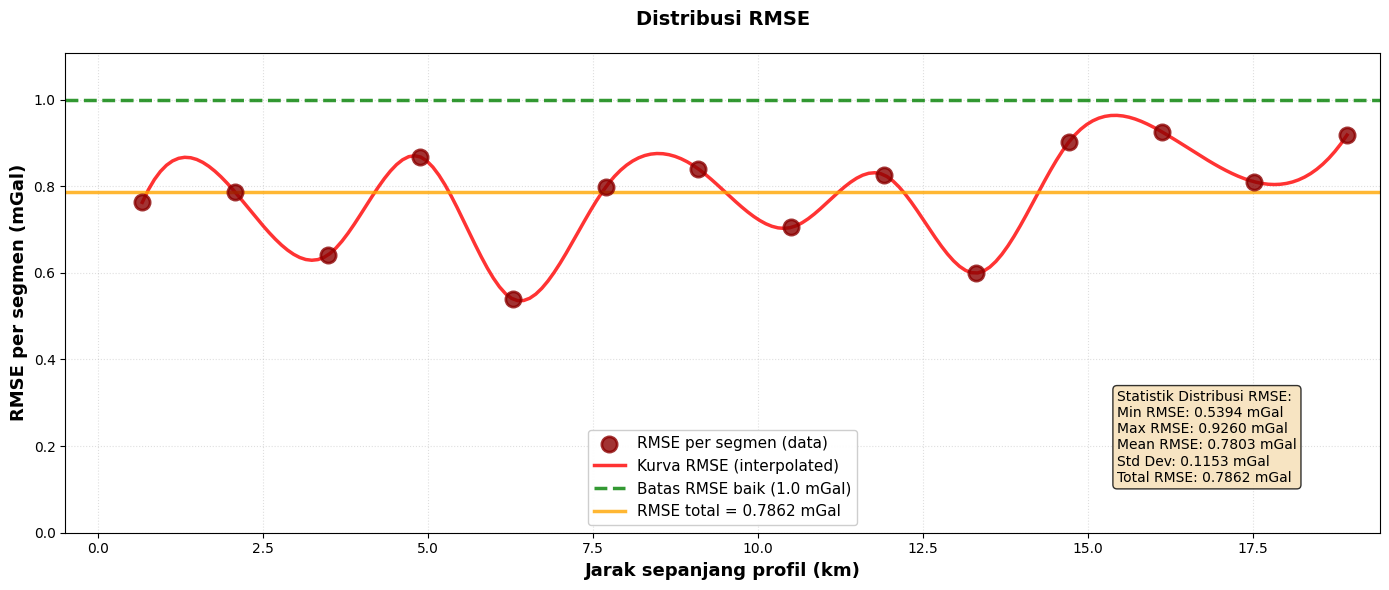

✓ Grafik distribusi RMSE (line chart) berhasil dibuat!

Ringkasan RMSE per segmen:
Pos. (km)    RMSE (mGal)   
--------------------------
0.67         0.7628        
2.07         0.7869        
3.48         0.6408        
4.88         0.8678        
6.29         0.5394        
7.69         0.7978        
9.10         0.8401        
10.50        0.7048        
11.90        0.8265        
13.31        0.5996        
14.71        0.9026        
16.12        0.9260        
17.52        0.8103        
18.93        0.9183        


In [13]:
# ── Plot RMSE per segmen DENGAN GRAFIK GARIS ──
segment_size = 20
rmse_segments = []
x_segments = []

for i in range(0, len(x_profile) - segment_size, segment_size):
    seg_obs = anom_observed[i:i+segment_size]
    seg_calc = anom_calc_shifted[i:i+segment_size]
    rmse_segments.append(compute_rmse(seg_obs, seg_calc))
    x_segments.append(np.mean(x_profile[i:i+segment_size]))

# ── Interpolasi untuk smoothing kurva ──
if len(x_segments) > 1:
    # Gunakan spline interpolation untuk kurva yang lebih smooth
    f_interp = interp1d(x_segments, rmse_segments, kind='cubic', fill_value='extrapolate')
    x_smooth = np.linspace(min(x_segments), max(x_segments), 200)
    rmse_smooth = f_interp(x_smooth)
else:
    x_smooth = x_segments
    rmse_smooth = rmse_segments

# ── Buat plot grafik garis profesional ──
fig, ax = plt.subplots(figsize=(14, 6))

# Plot data segmen sebagai scatter points
ax.scatter(x_segments, rmse_segments, s=120, color='darkred', zorder=3, 
           edgecolors='darkred', linewidth=2, label='RMSE per segmen (data)', alpha=0.8)

# Plot interpolated curve
ax.plot(x_smooth, rmse_smooth, 'r-', lw=2.5, label='Kurva RMSE (interpolated)', alpha=0.8)

# Garis threshold RMSE baik
ax.axhline(1.0, color='green', lw=2.5, ls='--', alpha=0.8, label='Batas RMSE baik (1.0 mGal)')

# Garis RMSE total
ax.axhline(rmse, color='orange', lw=2.5, ls='-', alpha=0.8, label=f'RMSE total = {rmse:.4f} mGal')

# Format plot
ax.set_xlabel('Jarak sepanjang profil (km)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE per segmen (mGal)', fontsize=13, fontweight='bold')
ax.set_title('Distribusi RMSE', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='lower center', framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle=':')
ax.set_xlim(-0.5, max(x_segments) + 0.5)
ax.set_ylim(0, max(rmse_smooth) * 1.15)

# Tambah informasi statistik di plot
stats_text = f"""Statistik Distribusi RMSE:
Min RMSE: {min(rmse_segments):.4f} mGal
Max RMSE: {max(rmse_segments):.4f} mGal
Mean RMSE: {np.mean(rmse_segments):.4f} mGal
Std Dev: {np.std(rmse_segments):.4f} mGal
Total RMSE: {rmse:.4f} mGal"""

ax.text(0.8, 0.1, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('05_rmse_distribusi_grafik.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Grafik distribusi RMSE (line chart) berhasil dibuat!")
print(f"\nRingkasan RMSE per segmen:")
print(f"{'Pos. (km)':<12} {'RMSE (mGal)':<14}")
print("-" * 26)
for x, r in zip(x_segments, rmse_segments):
    print(f"{x:<12.2f} {r:<14.4f}")